<a href="https://colab.research.google.com/github/Saptarishi-S/Tredence-Problem/blob/main/Tredence_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [139]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)

        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / fan_in**0.5
            nn.init.uniform_(self.bias, -bound, bound)

        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)

        pruned_weight = self.weight * gates

        return F.linear(x, pruned_weight, self.bias)

In [140]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super(PrunableMLP, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(3 * 32 * 32, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [141]:
def get_all_gates(model):
    gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates.append(torch.sigmoid(module.gate_scores))

    return gates

In [142]:
def compute_sparsity_loss(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            all_gates.append(gates.view(-1))

    all_gates = torch.cat(all_gates)

    return all_gates.mean()

In [143]:
def compute_total_loss(outputs, targets, model, lambda_sparse):
    classification_loss = F.cross_entropy(outputs, targets)
    sparsity_loss = compute_sparsity_loss(model)

    total_loss = classification_loss + lambda_sparse * sparsity_loss

    return total_loss, classification_loss, sparsity_loss

In [144]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [145]:
from tqdm import tqdm

def train_model(lambda_sparse, epochs=10):
    model = PrunableMLP().to(device)

    gate_params = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    other_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    optimizer = torch.optim.Adam([
        {'params': other_params, 'lr': 1e-3},
        {'params': gate_params, 'lr': 1e-2}
    ])


    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            total_loss, cls_loss, sp_loss = compute_total_loss(
                outputs, labels, model, lambda_sparse
            )

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix({
                "loss": f"{total_loss.item():.4f}",
                "cls": f"{cls_loss.item():.4f}",
                "sp": f"{sp_loss.item():.4f}"
            })

        train_acc = 100 * correct / total
        val_acc = evaluate_model(model)
        sparsity = compute_sparsity(model)

        with torch.no_grad():
            gates = collect_all_gate_values(model)
            min_gate = gates.min().item()
            mean_gate = gates.mean().item()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Loss: {running_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Val Acc: {val_acc:.2f}% "
            f"| Sparsity: {sparsity:.2f}% "
            f"| Min Gate: {min_gate:.4f} "
            f"| Mean Gate: {mean_gate:.4f}"
        )

    return model

In [146]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [147]:
def compute_sparsity(model, threshold=0.1):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [148]:
def collect_all_gate_values(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu()
            all_gates.append(gates.view(-1))

    return torch.cat(all_gates)

In [149]:
lambdas = [0.1, 0.5, 2.0]
results = []

best_model = None
best_acc = 0
best_gates = None

for lam in lambdas:

    model = train_model(lambda_sparse=lam, epochs=10)

    acc = evaluate_model(model)
    sparsity = compute_sparsity(model)

    print(f"\nFinal → Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%\n")

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_gates = collect_all_gate_values(model)

Epoch [1/10]: 100%|██████████| 391/391 [00:35<00:00, 10.99it/s, loss=1.6411, cls=1.5955, sp=0.4556]


Epoch [1/10] | Loss: 663.1567 | Train Acc: 41.28% | Val Acc: 47.50% | Sparsity: 0.00% | Min Gate: 0.1113 | Mean Gate: 0.4555


Epoch [2/10]: 100%|██████████| 391/391 [00:37<00:00, 10.39it/s, loss=1.5380, cls=1.4952, sp=0.4281]


Epoch [2/10] | Loss: 565.2521 | Train Acc: 50.50% | Val Acc: 50.67% | Sparsity: 0.18% | Min Gate: 0.0520 | Mean Gate: 0.4280


Epoch [3/10]: 100%|██████████| 391/391 [00:36<00:00, 10.73it/s, loss=1.4494, cls=1.4089, sp=0.4056]


...

Epoch [8/10] | Loss: 426.2372 | Train Acc: 67.50% | Val Acc: 56.88% | Sparsity: 76.44% | Min Gate: 0.0015 | Mean Gate: 0.0827


Epoch [9/10]: 100%|██████████| 391/391 [00:34<00:00, 11.34it/s, loss=1.1031, cls=0.9451, sp=0.0790]


Epoch [9/10] | Loss: 398.1365 | Train Acc: 69.58% | Val Acc: 56.42% | Sparsity: 77.84% | Min Gate: 0.0011 | Mean Gate: 0.0790


Epoch [10/10]: 100%|██████████| 391/391 [00:36<00:00, 10.66it/s, loss=0.8897, cls=0.7376, sp=0.0760]


Epoch [10/10] | Loss: 373.0303 | Train Acc: 71.88% | Val Acc: 57.07% | Sparsity: 78.99% | Min Gate: 0.0008 | Mean Gate: 0.0760

Final → Lambda: 2.0 | Accuracy: 57.07% | Sparsity: 78.99%



In [150]:
print("\nFinal Results:\n")
print("Lambda\t\tAccuracy (%)\tSparsity (%)")

for lam, acc, sp in results:
    print(f"{lam}\t\t{acc:.2f}\t\t{sp:.2f}")


Final Results:

Lambda		Accuracy (%)	Sparsity (%)
0.1		56.40		13.70
0.5		56.62		45.22
2.0		57.07		78.99


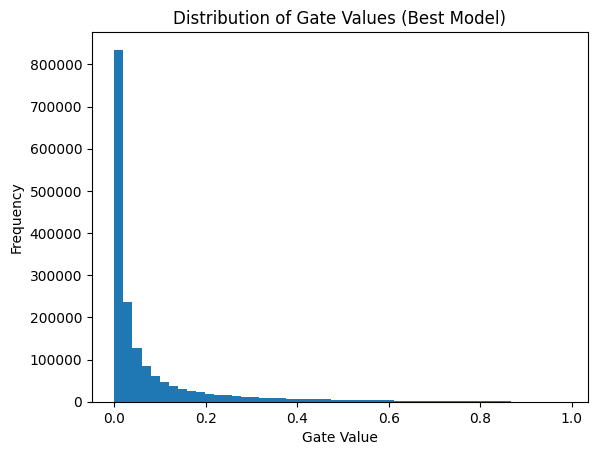

In [151]:
import matplotlib.pyplot as plt

plt.hist(best_gates.numpy(), bins=50)
plt.title("Distribution of Gate Values (Best Model)")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()